In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
import pandas as pd
from scipy.stats import norm
import corner

In [2]:
import dynesty

from dynesty import utils as dyfunc
from dynesty import plotting as dyplot

In [3]:
path = '../solutions/transient.npy'

In [4]:
data = np.load(path)
np.shape(data)
times = []
F = []
sF = []
for i in range(100):
    times = np.append(times,data[i][0])
    F = np.append(F,data[i][1])
    sF = np.append(sF,data[i][2])

In [5]:
def burst(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

def gprofile(theta,t):
    A,b,t0,sigmaW=theta     
    return b+A*np.exp(-(((t-t0)/sigmaW)**2 ) / 2)

In [6]:
t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)

sigmaWmin,sigmaWmax=np.exp(-2),np.exp(2)

In [7]:
def loglike(theta, data, model):
    x, y, sigma_y = data.T
    if model =='burst':
        y_fit = burst(theta, x)
    elif model == 'gprofile':
        y_fit = gprofile(theta, x)
        
    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 ) 


def ptform(u,model):
    x = np.array(u)  # copy u

    x[0] = scipy.stats.uniform(loc=Amin,scale=Amax-Amin).ppf(u[0])
    x[1] = scipy.stats.uniform(loc=bmin,scale=bmax-bmin).ppf(u[1])
    x[2] = scipy.stats.uniform(loc=t0min,scale=t0max-t0min).ppf(u[2])
   
    if model =='burst':
        x[3] = scipy.stats.loguniform.ppf(u[3],alphamin,alphamax)
    elif model =='gprofile':
        x[3] = scipy.stats.loguniform.ppf(u[3],sigmaWmin,sigmaWmax)
    return x

In [8]:
ndim = 4

In [9]:
import warnings

# Burst model

In [10]:
with warnings.catch_warnings():
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Define and run sampler
    sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'burst'],ptform_args=['burst'],nlive=300)
    sampler.run_nested()
    sresults = sampler.results

2453it [02:32,  1.88s/it, bound: 143 | nc: 452 | ncall: 79031 | eff(%):  3.104 | loglstar:   -inf < -86.598 <    inf | logz: -93.524 +/-  0.139 | dlogz: 34.533 >  0.309]/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2571it [02:56,  4.70it/s, bound: 162 | nc: 79 | ncall: 91284 | eff(%):  2.816 | loglstar:   -inf < -84.144 <    inf | logz: -93.236 +/-  0.144 | dlogz: 33.857 >  0.309] /home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstr

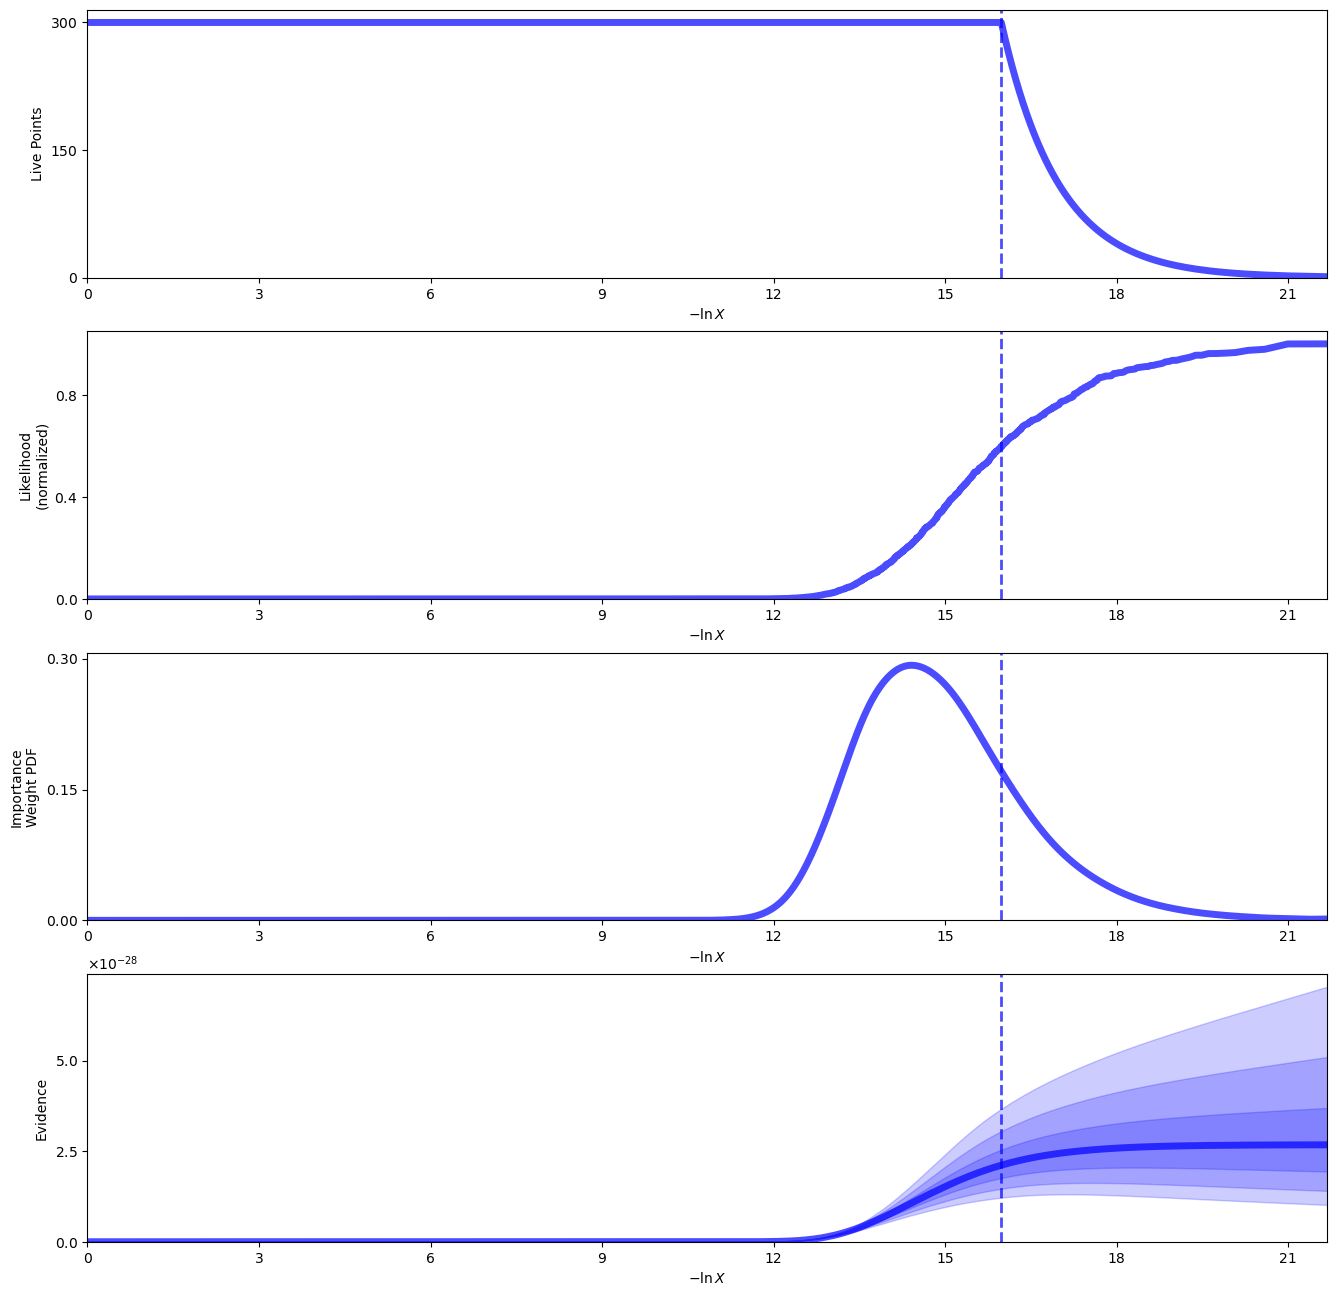

In [11]:
rfig, raxes = dyplot.runplot(sresults)

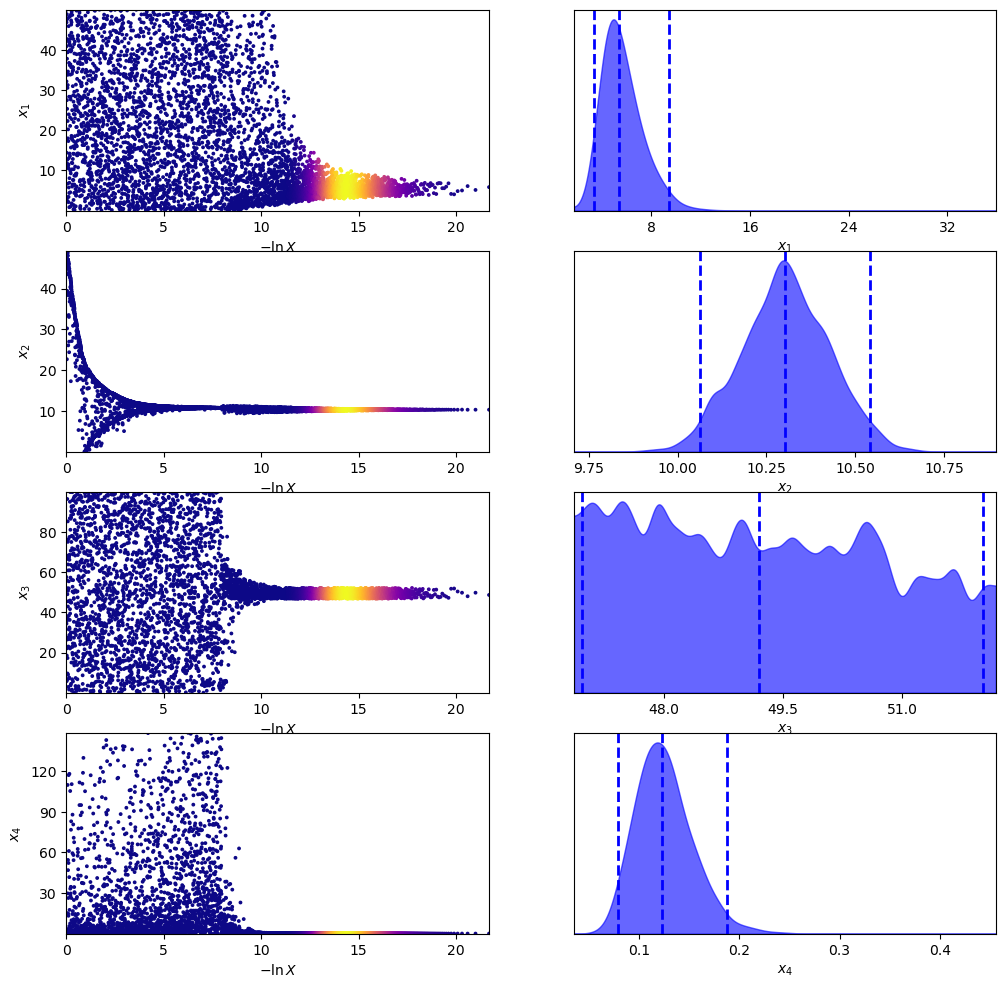

In [12]:
tfig, taxes = dyplot.traceplot(sresults)

In [13]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))


Bayesian evidence 2.676095741149861e-28
68% parameter credible regions are:
 [[4.190933974423742, 7.161332088377408], [10.178016008371486, 10.42388595517222], [47.53524349750141, 51.06365535783], [0.09776766407607242, 0.1522760976593489]]

Mean and covariance of parameters are: [ 5.63695761 10.3025777  49.27939894  0.12518382]
[[ 2.56584502e+00  1.55809564e-02 -1.62974540e+00  2.58426548e-02]
 [ 1.55809564e-02  1.50233275e-02  1.06313446e-03  1.45025380e-03]
 [-1.62974540e+00  1.06313446e-03  2.27187196e+00 -1.04647619e-03]
 [ 2.58426548e-02  1.45025380e-03 -1.04647619e-03  8.05585695e-04]]


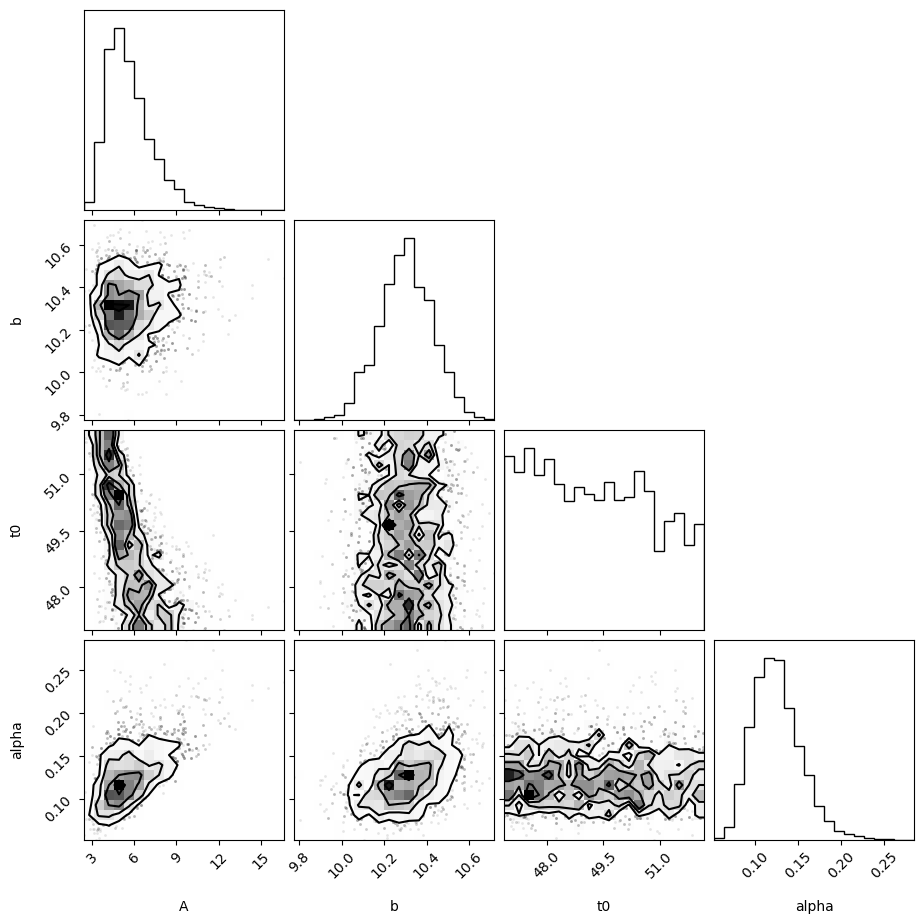

In [14]:
labels = ["A","b","t0","alpha"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [15]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

A   5.343067733228676 +3.3629924236145374 -1.7388672848286855
b   10.302657752146096 +0.20156485758262832 -0.20737578674552992
t0   49.194927022767395 +2.585423295362183 -2.1184087995487104
alpha   0.12230559595337277 +0.053845503215511195 -0.03792394897065332


In [16]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = dyfunc.quantile(samples[:,i], [0.05, 0.5, 0.95], weights=weights)
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [17]:
sresults.summary()

Summary
nlive: 300
niter: 4802
ncall: 131550
eff(%):  3.878
logz: -63.488 +/-  0.323


# Gaussian

In [18]:
with warnings.catch_warnings():
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'gprofile'],ptform_args=['gprofile'],nlive=300)
    sampler.run_nested()
    sresults2 = sampler.results

2448it [01:31,  4.29it/s, bound: 99 | nc: 66 | ncall: 47703 | eff(%):  5.132 | loglstar:   -inf < -86.383 <    inf | logz: -94.383 +/-  0.150 | dlogz: 31.487 >  0.309] /home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2449it [01:32,  3.89it/s, bound: 100 | nc: 182 | ncall: 47885 | eff(%):  5.114 | loglstar:   -inf < -86.380 <    inf | logz: -94.380 +/-  0.150 | dlogz: 31.481 >  0.309]/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstra

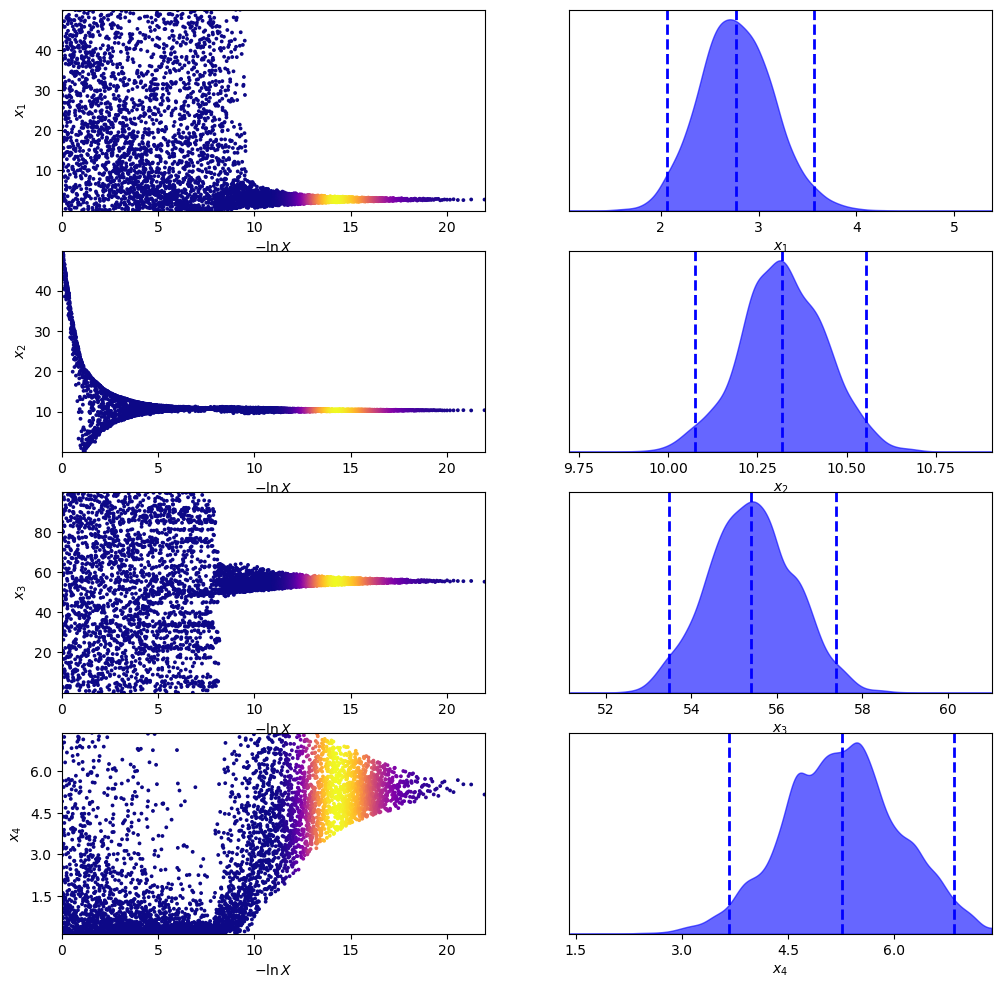

In [19]:
tfig, taxes = dyplot.traceplot(sresults2)

In [20]:
samples2 = sresults2.samples  # samples
weights2 = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights

evidence2 = sresults2.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence2))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights2)
             for samps in samples2.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples2, weights2)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))


Bayesian evidence 4.8425408636317286e-30
68% parameter credible regions are:
 [[2.4129377060007777, 3.1397075297717185], [10.209827851539668, 10.440281666214286], [54.40516661091333, 56.44170189011067], [4.472809319223487, 6.0953884085397165]]

Mean and covariance of parameters are: [ 2.77453643 10.32103246 55.39818485  5.25480619]
[[ 0.14182686 -0.01101238 -0.12735825 -0.12575709]
 [-0.01101238  0.01415941 -0.01415641 -0.03393832]
 [-0.12735825 -0.01415641  0.99592271  0.28484487]
 [-0.12575709 -0.03393832  0.28484487  0.66439394]]


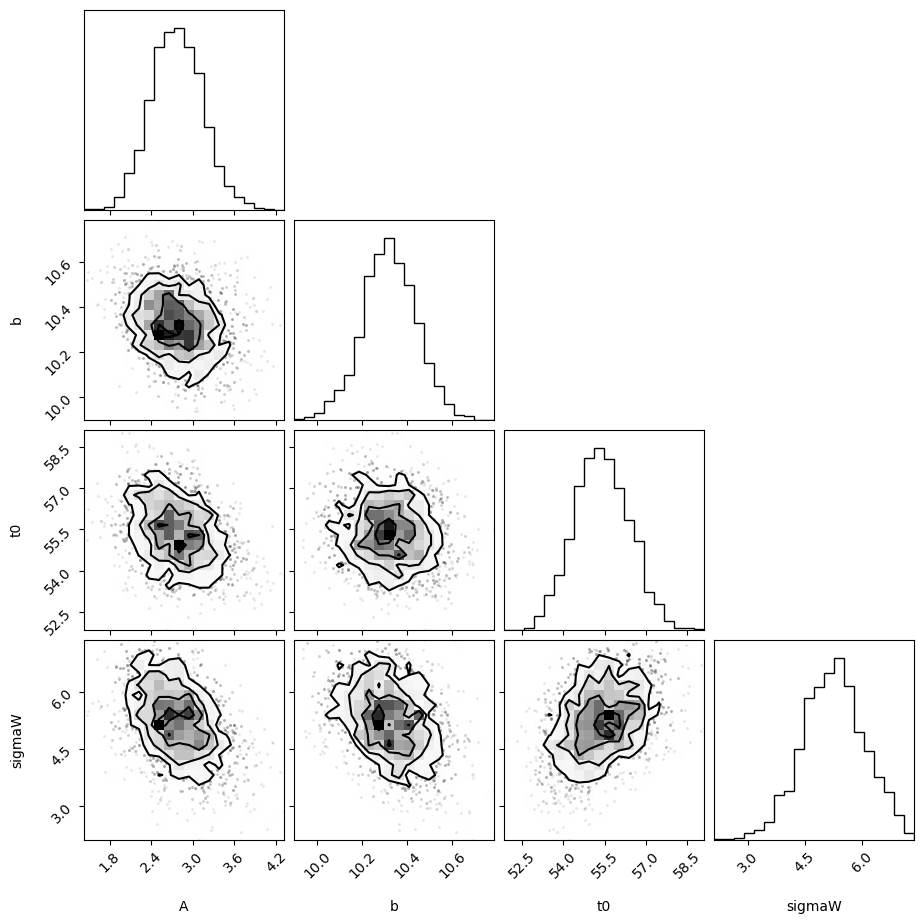

In [21]:
labels = ["A","b","t0","sigmaW"]

samples2_equal = dyfunc.resample_equal(samples2, weights2)
corner.corner(samples2_equal,labels=labels);

In [22]:
for i in range(ndim):
    mcmc = dyfunc.quantile(samples2[:,i], [0.05, 0.5, 0.95], weights=weights2)
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [23]:
sresults2.summary()

Summary
nlive: 300
niter: 4884
ncall: 92242
eff(%):  5.620
logz: -67.500 +/-  0.322


In [24]:
# Final Comparison
# odds ratio between Burst and Gaussian --> the burst model is strongly favoured
np.exp(sresults.logz[-1])/np.exp(sresults2.logz[-1])

55.26222321111994

In [25]:
B = np.exp(sresults.logz[-1])/np.exp(sresults2.logz[-1])
if B > 100: print('Decisive')
elif B > 30: print('Very strong')
elif B > 10: print('Strong')
elif B > 3: print('Substantial')
elif B > 1: print('Barely worth mentioning')
else: print('Negative')

Very strong
